## **PRACTICAL SESSION 1** — Deep Learning for predictive maintenance

The dataset used is the **AI4I 2020** Predictive Maintenance Dataset, which contains 10,000 instances of industrial sensor data. Each instance represents the operating condition of a machine and is associated with a label indicating whether a failure has occurred and, if so, what type of failure it is.

The 5 possible labels are:



*   **TWF**: Tool Wear Failure
*   **HDF**: Heat Dissipation Failure
*   **PWF**: Power Failure
*   **OSF**: Overstrain Failure
*   **RNF**: Random Failure


The data is available on eCAMPUS as CSV file called: "ai4i2020.csv"



## **PRACTICAL SESSION Goal** — Ceate a deep leanring model allowing to realize a predictive maintenance mission

## **1 - Analysis of the dataset**



All libraries used ***SHOULD BE PLACED*** in the code cell below

In [1]:
# Importations de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn pour le prétraitement et l'évaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight


# TensorFlow et Keras pour le modèle de deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

**QUESTION:** Load dataset and display some lines of the csv file.

In [2]:
df = pd.read_csv("ai4i2020.csv")
# Display the first 5 rows
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

**QUESTION:** Display the distribution of machine failures and non-failures with a bar graph.

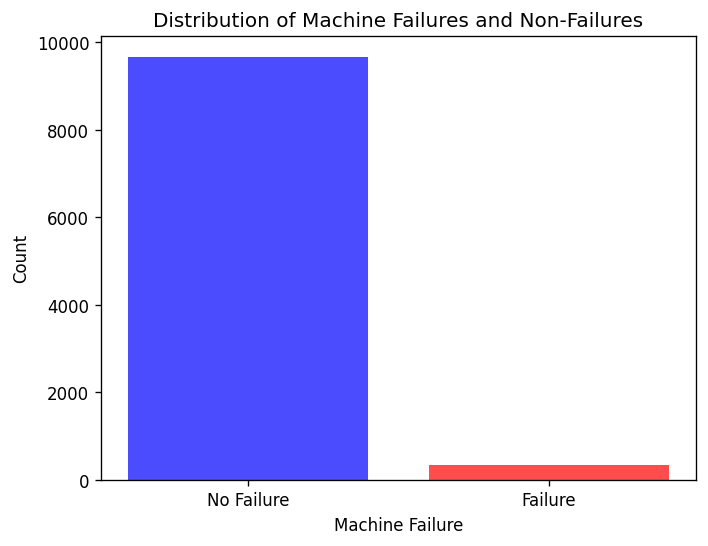

In [3]:
# On compte le nombre de pannes et de non-pannes
failure_counts = df["Machine failure"].value_counts()
# On affiche la distribution sous forme de barres
plt.figure(dpi = 120)
plt.bar(["No Failure", "Failure"], failure_counts, alpha=0.7, color=['blue', 'red'])
plt.xlabel("Machine Failure")
plt.ylabel("Count")
plt.title("Distribution of Machine Failures and Non-Failures")
plt.show()

**ANALYSIS QUESTION:** What do you observe?

The figure shows that the dataset has almost 20 times more non-failures than failures. This creates a very imbalanced Dataset which will later on affect the training of the models.

**ANALYSIS QUESTION:** What will be the consequence of this phenomenon on the model's learning?

Machine failures are very rare in the dataset so models are more prone to undermine failures. they will tend to favor non-failures since they dominate the dataset.

**QUESTION:** Create a bar chart showing the distribution of different failure types (TWF, HDF, PWF, OSF, RNF). Display the exact values above each bar in the chart."

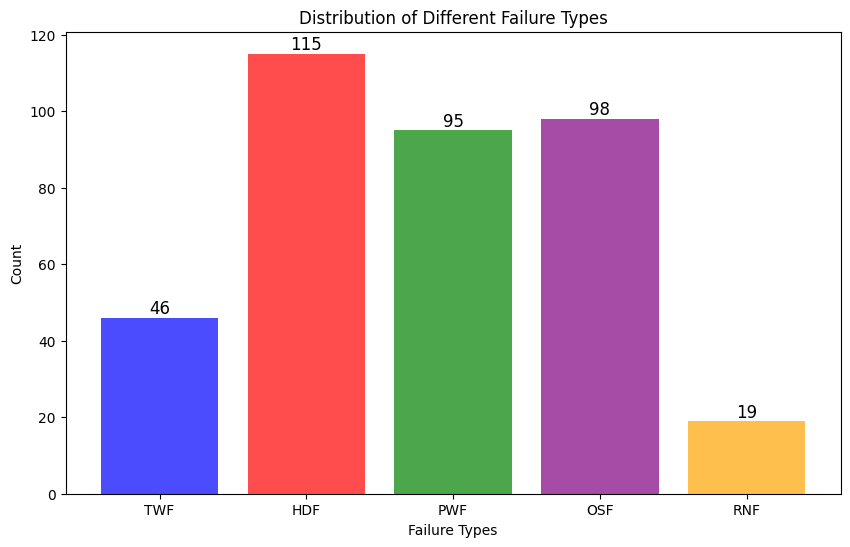

In [ ]:
failure_types = ["TWF", "HDF", "PWF", "OSF", "RNF"]
failure_counts = df[failure_types].sum()  # On ne compte que les types de panne spécifiques

plt.figure(figsize=(10, 6))
bars = plt.bar(failure_counts.index, failure_counts.values, alpha=0.7, color=['blue', 'red', 'green', 'purple', 'orange'])

# Afficher les valeurs au-dessus de chaque barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom', fontsize=12)

# Labels and title
plt.xlabel("Failure Types")
plt.ylabel("Count")
plt.title("Distribution of Different Failure Types")
# Show plot
plt.show()

**ANALYSIS QUESTION:** What do you observe?

HDF (Heat Dissipation Failure) is the most common failure type with 115 occurrences. Heat is the biggest reason behind system failures. PWF (Power Failure) and OSF (Overstrain Failure) are also as frequent, with 95 and 98 cases respectively. Power-related and mechanical stress issues are major contributors to failures as well. TWF (Tool Wear Failure) is half as frequent with 46 occurrences, meaning tool degradation is not a common cause. Finally,
RNF (Random Failure) is the least common, with only 19 cases, showing that unexpected failures are rare.

**QUESTION:** Create a bar chart showing the distribution of failure types (TWF, HDF, PWF, OSF, RNF) among machines that experienced a failure (Machine failure == 1). Additionally, add a "No Specific Failure" category to count cases where a machine failed but no specific failure type was recorded. Display the exact values above each bar in the chart."

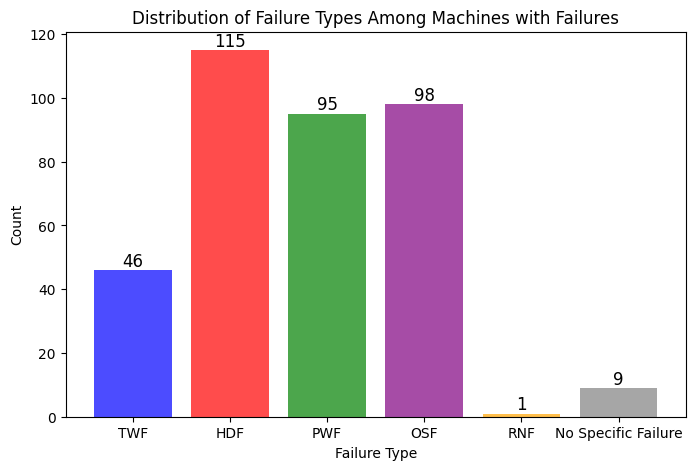

In [ ]:
# Filtrer uniquement les machines qui ont eu une panne (Machine failure == 1)
failed_machines = df[df["Machine failure"] == 1]

# On compte les occurrences de chaque type de panne
failure_types = ["TWF", "HDF", "PWF", "OSF", "RNF"]
failure_counts = failed_machines[failure_types].sum()

# On ajoute la catégorie "No Specific Failure" (cas où Machine failure == 1 mais aucune panne spécifique)
no_specific_failure_count = (failed_machines[failure_types].sum(axis=1) == 0).sum()
failure_counts["No Specific Failure"] = no_specific_failure_count

# bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(failure_counts.index, failure_counts.values, alpha=0.7, color=['blue', 'red', 'green', 'purple', 'orange', 'gray'])

# On ajoute les valeurs au-dessus de chaque barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom', fontsize=12)

plt.xlabel("Failure Type")
plt.ylabel("Count")
plt.title("Distribution of Failure Types Among Machines with Failures")
plt.show()

**ANALYSIS QUESTION:** What do you observe compared to the previous question ? What can you conclude?

We observe that some machines failed but were not assigned any specific failure type. The presence of "No Specific Failure" cases suggests issues with data labeling or the dataset structure. Some failures might be due to unknown failure types, multiple simultaneous failures, or external factors not captured by the sensors. The data annotation is lacking. Feature engineering should also be refined to improve model accuracy.

**QUESTION:** Display the names of the different columns in the dataset with their respective data types.

In [ ]:
column_info = pd.DataFrame({"Column Name": df.columns, "Data Type": df.dtypes.values})
print(column_info)

                Column Name Data Type
0                       UDI     int64
1                Product ID    object
2                      Type    object
3       Air temperature [K]   float64
4   Process temperature [K]   float64
5    Rotational speed [rpm]     int64
6               Torque [Nm]   float64
7           Tool wear [min]     int64
8           Machine failure     int64
9                       TWF     int64
10                      HDF     int64
11                      PWF     int64
12                      OSF     int64
13                      RNF     int64


**ANALYSIS QUESTION:** To train the model, what will be the inputs and outputs (What are the names of the columns that you will use?)? Justify your response.
Remember, you want to predict if the machine will fail, and if so, what kind of failure. You need to yse previous results to jsurtify your response.

The model will use machine condition and operational metrics as inputs, specifically air temperature (K), process temperature (K), rotational speed (rpm), torque (Nm), and tool wear (minutes), as each of these variables could indicate potential issues influencing machine functionality.

The outputs will be the columns indicating whether a machine failure has occurred (Machine failure: 0 for no failure, 1 for failure) and the type of failure involved: tool wear failure (TWF), heat dissipation failure (HDF), power failure (PWF), overstrain failure (OSF), and random failure (RNF). If a machine failure occurs, at least one of these specific failure indicators will also show a positive result (value of 1).

## **2- Train model Without balancing the dataset**

---



In this section, you must build and train a model without rebalancing the dataset.

**QUESTION:** Create X_train, Y_train, X_test, and Y_test. How many elements are present in X_train, Y_train, X_test, and Y_test? (Print the values)

In [ ]:
# Define Inputs (Features - X) and Outputs (Target - Y)
X = df[["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]",
        "Torque [Nm]", "Tool wear [min]"]]

# Créer une colonne "No Failure" (inverse de "Machine failure")
df["No Failure"] = (df["Machine failure"] == 0).astype(int)

# Définir les cibles : No Failure et les 4 types de pannes spécifiques
Y = df[["No Failure", "TWF", "HDF", "PWF", "OSF"]]

# Split dataset (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y["No Failure"])
# Print the number of elements in each set
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape: (8000, 5)
Y_train shape: (8000, 5)
X_test shape: (2000, 5)
Y_test shape: (2000, 5)


**QUESTION** Code below the model architecture

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.4),

    keras.layers.Dense(Y_train.shape[1], activation='sigmoid')
])

optimizer = keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['binary_accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**QUESTION** Code below the algorithms allowing to train model

**WARNING!** You need to plot the training and test accuracy and loss to check if our model is overfitting

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - binary_accuracy: 0.5880 - loss: 0.7771 - val_binary_accuracy: 0.4791 - val_loss: 1.1489
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7946 - loss: 0.5658 - val_binary_accuracy: 0.9749 - val_loss: 0.3811
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9332 - loss: 0.3723 - val_binary_accuracy: 0.9862 - val_loss: 0.2066
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9698 - loss: 0.2391 - val_binary_accuracy: 0.9860 - val_loss: 0.1351
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.9803 - loss: 0.1576 - val_binary_accuracy: 0.9859 - val_loss: 0.1053
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9850 - loss: 0.1151 - val_binary_accuracy: 0.9859 - val_loss: 0.0846
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9839 - loss: 0.0997 - val_binary_accuracy: 0.9859 - val_loss: 0.078

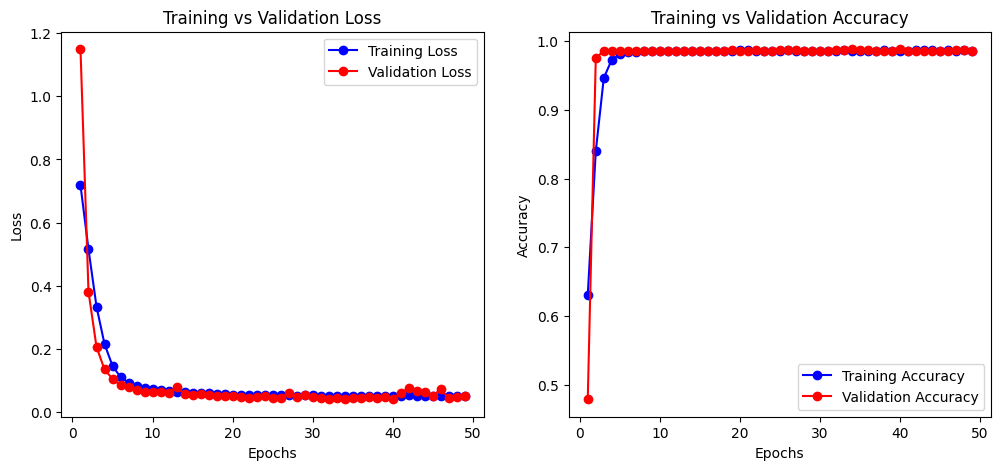

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_test, Y_test),
    callbacks=[early_stopping],
    verbose=1
)

# Extract loss and accuracy values
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']

epochs = range(1, len(train_loss) + 1)

# Plot Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()


**QUESTION** Plot the confusion matrix and the classification report

**Tips:**

*   classification report link

> https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

*   Matrix confusion

> https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html





63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


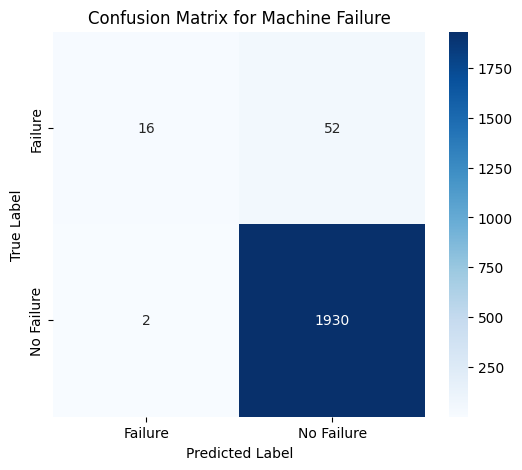

Classification Report:
               precision    recall  f1-score   support

  No Failure       0.97      1.00      0.99      1932
         TWF       0.00      0.00      0.00         9
         HDF       0.00      0.00      0.00        21
         PWF       0.83      0.23      0.36        22
         OSF       1.00      0.24      0.38        21

   micro avg       0.97      0.97      0.97      2005
   macro avg       0.56      0.29      0.35      2005
weighted avg       0.96      0.97      0.96      2005
 samples avg       0.97      0.97      0.97      2005



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Predict on test data
Y_pred_probs = model.predict(X_test)
Y_pred = (Y_pred_probs > 0.5).astype(int)  # Convert probabilities to binary (0 or 1)

# Compute the confusion matrix for "Machine failure" (the main target)
cm = confusion_matrix(Y_test["No Failure"], Y_pred[:, 0])  # Assuming "Machine failure" is the first column

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Failure','No Failure'], yticklabels=['Failure','No Failure'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Machine Failure')
plt.show()

# Generate classification report
report = classification_report(Y_test, Y_pred, target_names=Y_test.columns)
print("Classification Report:\n", report)

**ANALYSIS QUESTION** What do you observe? What can you conclude?

The confusion matrix and classification report indicate that the model is overfitting to the majority class. It has learned to predict "No Failure" (0) in most cases while failing to detect actual failures. This happens because the dataset is highly imbalanced, with far more instances of non-failure than failure. As a result, the model optimizes for overall accuracy rather than learning meaningful patterns that distinguish failures. While it achieves a high accuracy of 97%, this is misleading because the recall for failures is extremely low (only 9%). The model struggles to generalize, failing to correctly classify rare failures, which is evident from the fact that some failure types have 0% recall, meaning the model never predicts them. Additionally, the warnings about undefined precision indicate that certain failure types are completely ignored by the model. This overfitting issue arises because the model is biased toward the dominant class, leading to poor generalization in real-world predictive maintenance scenarios.

## **3- Train model With balancing the dataset**

---

 Methods for rebalancing a dataset:


*   Use oversampling techniques (e.g., SMOTE) to generate synthetic data for minority classes


> https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html



*   Apply undersampling techniques (e.g., random undersampling, Tomek Links, Edited Nearest Neighbors) to reduce the majority class size



> https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html



*   Use class weighting during model training to penalize errors on minority classes



> https://www.tensorflow.org/tutorials/structured_data/imbalanced_data?hl=fr


**QUESTION:** Create X_train, Y_train, X_test, and Y_test. How many elements are present in X_train, Y_train, X_test, and Y_test? (Print the values)

In [4]:
# Define Inputs (Features - X) and Outputs (Target - Y)
X = df[["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]",
        "Torque [Nm]", "Tool wear [min]"]]

# Créer une colonne "No Failure" (inverse de "Machine failure")
df["No Failure"] = (df["Machine failure"] == 0).astype(int)

# Définir les cibles : No Failure et les 4 types de pannes spécifiques
Y = df[["No Failure", "TWF", "HDF", "PWF", "OSF"]]

# Split dataset (80% train, 20% test)
X_train_raw, X_test, Y_train_raw, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Normalisation des données avant application de SMOTE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test)

# Créer un DataFrame temporaire pour la conversion
temp_df = Y_train_raw.copy()

# Identifier les lignes sans pannes et celles avec différents types de pannes
temp_df['failure_type'] = 'No Failure'  # Par défaut

# Pour chaque type de panne, remplacer la valeur par le type de panne s'il est présent
for failure_type in ["TWF", "HDF", "PWF", "OSF"]:
    temp_df.loc[temp_df[failure_type] == 1, 'failure_type'] = failure_type

# 1. D'abord, appliquer un undersampling sur la classe "No Failure" pour réduire sa taille de moitié

# Configurer RandomUnderSampler
rus = RandomUnderSampler(
    sampling_strategy={'No Failure': 5000},
    random_state=42
)
X_train_undersampled, y_train_type_undersampled = rus.fit_resample(X_train_scaled, temp_df['failure_type'])

# 2. Ensuite, appliquer SMOTE pour équilibrer toutes les classes
sm = SMOTE(random_state=42)
X_train_resampled, y_train_type_resampled = sm.fit_resample(X_train_undersampled, y_train_type_undersampled)

# Convertir le résultat en colonnes binaires
y_train_resampled = pd.get_dummies(y_train_type_resampled, prefix='', prefix_sep='')

# Renommer les colonnes pour correspondre aux noms d'origine si nécessaire
column_mapping = {}
for col in y_train_resampled.columns:
    if col == 'No Failure':
        column_mapping[col] = 'No Failure'
    else:
        column_mapping[col] = col

y_train_resampled = y_train_resampled.rename(columns=column_mapping)

# Réorganiser les colonnes pour correspondre à l'ordre d'origine
y_train_resampled = y_train_resampled[["No Failure", "TWF", "HDF", "PWF", "OSF"]]

# Afficher les dimensions des ensembles de données
print(f"X_train shape after resampling: {X_train_resampled.shape}")
print(f"Y_train shape after resampling: {y_train_resampled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")
print(f"Y_test shape: {Y_test.shape}")

# Vérifier la distribution des classes après rééquilibrage
print("\nDistribution des classes après rééquilibrage:")
for col in ["No Failure", "TWF", "HDF", "PWF", "OSF"]:
    print(f"{col}: {y_train_resampled[col].sum()}")

X_train shape after resampling: (25000, 5)
Y_train shape after resampling: (25000, 5)
X_test shape: (2000, 5)
Y_test shape: (2000, 5)

Distribution des classes après rééquilibrage:
No Failure: 5000
TWF: 5000
HDF: 5000
PWF: 5000
OSF: 5000


**ANALYSIS QUESTION:** Explain the choices you made to balance the dataset.

We need to balance the dataset to overcome the overfitting problem. SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic examples for the minority class. That way we have an equal distribution of failed and non-failed machines. This choice was necessary because the original dataset was highly imbalanced, causing the model to favor predicting "No Failure" while failing to detect actual failures. We first normalized the features to ensure SMOTE-generated samples remained within a realistic range. Then, we applied SMOTE separately to each failure type to preserve their individual distributions and prevent over-representation of any specific failure mode. This way the model is able to recognize failures while maintaining a representative dataset structure. That will lead to a more generalizable and reliable predictive maintenance model.

**QUESTION:** Code below the model architecture


**TIP:** It could be interesting to keep it the same as before

In [32]:
# Architecture du modèle avec quelques améliorations
model_balanced = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_resampled.shape[1],),
                kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),

    keras.layers.Dense(64, activation='relu',kernel_regularizer=l2(0.001)),
    keras.layers.BatchNormalization(),

    keras.layers.Dense(32, activation='relu',kernel_regularizer=l2(0.001)),
    keras.layers.BatchNormalization(),

    keras.layers.Dense(5, activation='sigmoid')
])

# Compilation avec les mêmes hyperparamètres que précédemment
optimizer = keras.optimizers.Adam(learning_rate=0.0008)
model_balanced.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

# Afficher le résumé du modèle
model_balanced.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                     │ (None, 128)                 │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_24               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_25               │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_26               │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 5)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,165 (47.52 KB)

 Trainable params: 11,717 (45.77 KB)

 Non-trainable params: 448 (1.75 KB)

**QUESTION** Code below the algorithms allowing to train model


Epoch 1/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - binary_accuracy: 0.8423 - loss: 0.5342 - val_binary_accuracy: 0.9294 - val_loss: 0.4327 - learning_rate: 8.0000e-04
Epoch 2/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.9854 - loss: 0.2100 - val_binary_accuracy: 0.9793 - val_loss: 0.1772 - learning_rate: 8.0000e-04
Epoch 3/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9919 - loss: 0.1302 - val_binary_accuracy: 0.9705 - val_loss: 0.1503 - learning_rate: 8.0000e-04
Epoch 4/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9929 - loss: 0.0947 - val_binary_accuracy: 0.9721 - val_loss: 0.1335 - learning_rate: 8.0000e-04
Epoch 5/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9930 - loss: 0.0773 - val_binary_accuracy: 0.9736 - val_loss: 0.1148 - learning_rate: 8.0000e-04
Epoch 6/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9940 - loss: 0.0639 - val_binary_accuracy: 0.9744 - val_loss: 0.1113 -

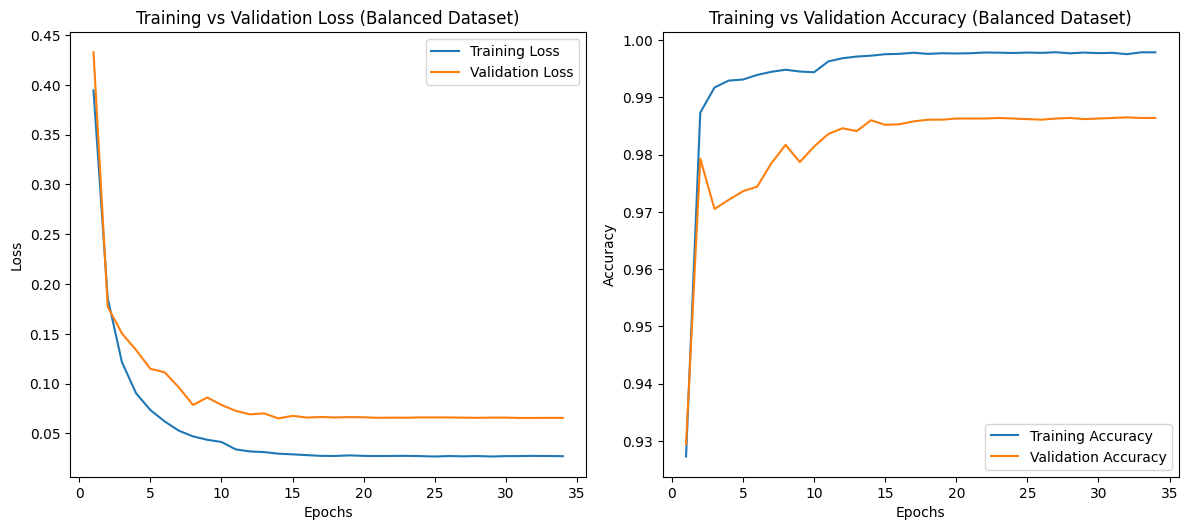

In [33]:
# Callbacks pour l'arrêt anticipé et la réduction du taux d'apprentissage
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# Ajout d'un scheduler pour réduire le learning rate
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,  # divise le learning rate par 10
    patience=2,  # attend 5 époques sans amélioration
    min_lr=1e-6,  # learning rate minimum
    verbose=1    # affiche un message lors de la réduction
)

# Entraînement du modèle
history_balanced = model_balanced.fit(
    X_train_resampled, y_train_resampled,
    epochs=100,
    batch_size=128,
    validation_data=(X_test_scaled, Y_test),
    callbacks=[early_stopping, reduce_lr],  # Ajout du callback reduce_lr
    verbose=1
)

# Extraction des valeurs de perte et de précision
train_loss = history_balanced.history['loss']
val_loss = history_balanced.history['val_loss']
train_acc = history_balanced.history['binary_accuracy']
val_acc = history_balanced.history['val_binary_accuracy']

# Extraction des valeurs du learning rate pour visualisation
lr_values = history_balanced.history.get('lr', [])

epochs = range(1, len(train_loss) + 1)

# Tracer les courbes de perte
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Balanced Dataset)')
plt.legend()

# Tracer les courbes de précision
plt.subplot(2, 2, 2)
plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy (Balanced Dataset)')
plt.legend()

# Tracer l'évolution du learning rate
if lr_values:
    plt.subplot(2, 2, 3)
    plt.plot(epochs, lr_values)
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate')
    plt.title('Learning Rate Evolution')
    plt.yscale('log')  # échelle logarithmique pour mieux visualiser les changements

plt.tight_layout()
plt.show()

**QUESTION** Plot the confusion matrix and the classification report

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


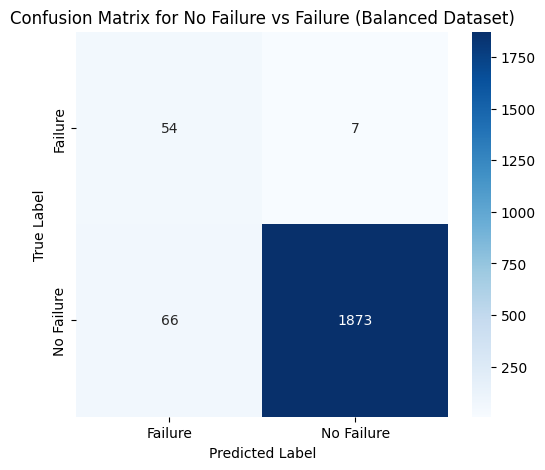

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report (Balanced Dataset):
               precision    recall  f1-score   support

  No Failure       1.00      0.97      0.98      1939
         TWF       0.12      0.36      0.18        11
         HDF       0.67      0.94      0.78        17
         PWF       0.61      0.85      0.71        20
         OSF       0.75      0.83      0.79        18

   micro avg       0.97      0.96      0.96      2005
   macro avg       0.63      0.79      0.69      2005
weighted avg       0.98      0.96      0.97      2005
 samples avg       0.96      0.96      0.96      2005


Modèle équilibré:
[[  54    7]
 [  66 1873]]


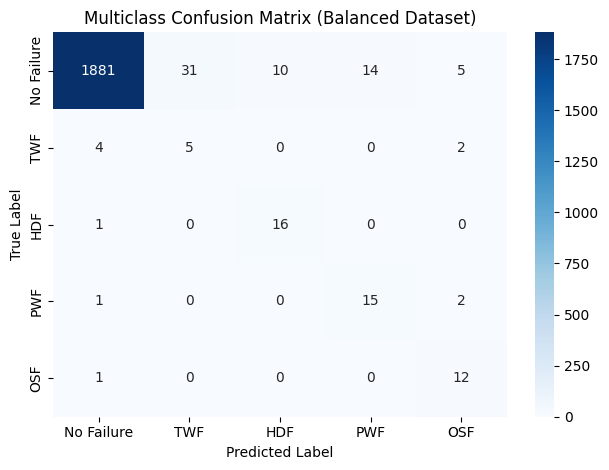

In [35]:
# Prédictions sur les données de test
Y_pred_probs_balanced = model_balanced.predict(X_test_scaled)
Y_pred_balanced = (Y_pred_probs_balanced > 0.5).astype(int)  # Conversion des probabilités en valeurs binaires

# Calcul de la matrice de confusion pour "No Failure"
cm_balanced = confusion_matrix(Y_test["No Failure"], Y_pred_balanced[:, 0])

# Affichage de la matrice de confusion
plt.figure(figsize=(6, 5))
import seaborn as sns
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Failure', 'No Failure'],  # Inversé car 0=Failure, 1=No Failure
            yticklabels=['Failure', 'No Failure'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for No Failure vs Failure (Balanced Dataset)')
plt.show()

# Génération du rapport de classification
report_balanced = classification_report(Y_test, Y_pred_balanced, target_names=Y_test.columns)
print("Classification Report (Balanced Dataset):\n", report_balanced)

# Comparaison avec le modèle précédent (si disponible)
print("\nModèle équilibré:")
print(cm_balanced)

# Création d'une matrice de confusion multiclasse
# Nous déterminons la classe prédite avec la plus haute probabilité parmi les 5
# D'abord, créons des étiquettes réelles simplifiées (une seule classe par échantillon)
y_true_multiclass = np.argmax(Y_test.values, axis=1)

# Puis créons des étiquettes prédites simplifiées
y_pred_multiclass = np.argmax(Y_pred_probs_balanced, axis=1)

# Calculons la matrice de confusion multiclasse
cm_multiclass = confusion_matrix(y_true_multiclass, y_pred_multiclass)

# Affichage de la matrice de confusion multiclasse
plt.figure(dpi=100)
sns.heatmap(cm_multiclass, annot=True, fmt='d', cmap='Blues',
            xticklabels=Y_test.columns,
            yticklabels=Y_test.columns)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Multiclass Confusion Matrix (Balanced Dataset)')
plt.tight_layout()
plt.show()

**ANALYSIS QUESTION** What do you observe? What can you conclude?

By using SMOTE, the model detects machine failures accurately. The confusion matrix indicates a balance between true positives and false negatives for failure detection. Most failures are no longer overlooked. The classification report shows improved recall and precision for failure classes. The model is more effective at distinguishing between different failure types. The balanced dataset lead to a more reliable predictive maintenance system that is capable of accurately predicting and categorizing machine failures. The model is a good solution to proactive maintenance strategies.